<a href="https://colab.research.google.com/github/bwecworkshop-dot/eventapplication/blob/main/stock_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))


Saving stock_data.csv to stock_data.csv
User uploaded file "stock_data.csv" with length 37728 bytes


In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))


In [8]:
import pandas as pd

data = pd.read_csv("stock_data.csv")
print(data.head())

   Unnamed: 0     Stock_1     Stock_2    Stock_3     Stock_4     Stock_5
0  2020-01-01  101.764052  100.160928  99.494642   99.909756  101.761266
1  2020-01-02  102.171269   99.969968  98.682973  100.640755  102.528643
2  2020-01-03  103.171258   99.575237  98.182139  100.574847  101.887811
3  2020-01-04  105.483215   99.308641  97.149381  100.925017  101.490049
4  2020-01-05  107.453175   98.188428  99.575396  101.594411  101.604283


In [9]:
print(data.shape)
print(data.columns)
print(data.info())

(365, 6)
Index(['Unnamed: 0', 'Stock_1', 'Stock_2', 'Stock_3', 'Stock_4', 'Stock_5'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  365 non-null    object 
 1   Stock_1     365 non-null    float64
 2   Stock_2     365 non-null    float64
 3   Stock_3     365 non-null    float64
 4   Stock_4     365 non-null    float64
 5   Stock_5     365 non-null    float64
dtypes: float64(5), object(1)
memory usage: 17.2+ KB
None


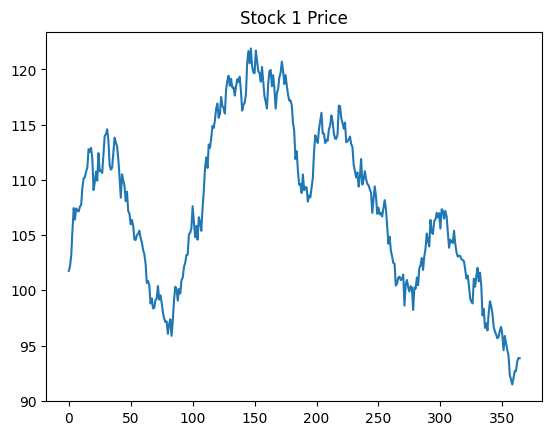

In [10]:
import matplotlib.pyplot as plt

plt.plot(data['Stock_1'])
plt.title("Stock 1 Price")
plt.show()

In [11]:
# Rename column
data.rename(columns={'Unnamed: 0': 'Date'}, inplace=True)

# Convert Date
data['Date'] = pd.to_datetime(data['Date'])

# Check nulls
print(data.isnull().sum())

# Select one stock
data = data[['Stock_1']]

Date       0
Stock_1    0
Stock_2    0
Stock_3    0
Stock_4    0
Stock_5    0
dtype: int64


In [12]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

X, y = [], []

for i in range(60, len(scaled_data)):
    X.append(scaled_data[i-60:i])
    y.append(scaled_data[i])

X, y = np.array(X), np.array(y)

print(X.shape, y.shape)

(305, 60, 1) (305, 1)


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(60,1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.fit(X, y, epochs=5, batch_size=32)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0949
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 0.0190
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0138
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0096
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0082


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step


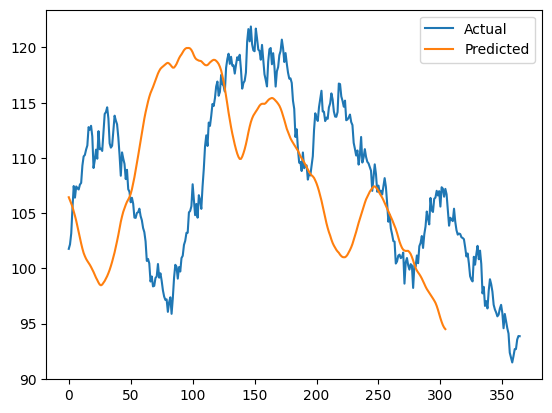

In [14]:
predictions = model.predict(X)
predictions = scaler.inverse_transform(predictions)

import matplotlib.pyplot as plt

plt.plot(data.values, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.show()

In [ ]:
from flask import Flask

app = Flask(__name__)

@app.route('/')
def home():
    return "Stock Prediction App Running!"

app.run(debug=True)